# Weight Estimation - Baseline

**Author:** Xián Novoa Gutiérrez  
**Project:** Poultry Vision Monitoring  
**Repository:** https://github.com/xiannovoa/poultry-vision-monitoring

## Introduction

In this notebook, we build a baseline pipeline for the task of chicken weight estimation from images using a Convolutional Neural Network (CNN).

The goal is to establish a simple reference solution, covering all key steps of a typical deep learning workflow. The notebook is structured into four main blocks:

1. **Dataset**: loading and preparing the dataset from local storage.
2. **Data Preparation for Training (PyTorch)**: transforming the data and creating custom PyTorch datasets and dataloaders.
3. **Train / Validation Split**: splitting the data to properly evaluate model performance on unseen samples.
4. **Target Normalization**: normalizing the weight values to improve training stability and convergence.

This baseline will serve as a starting point for further improvements in model architecture, training strategies, and data processing. The results obtained here highlight the limitations of a simple model and motivate further experimentation.

## 1. Dataset
https://huggingface.co/datasets/xiannovoa/poultry-weight-dataset

In [1]:
from datasets import load_dataset, Image
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
ROOT = Path.cwd().resolve()

while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATASET_PATH = ROOT / "data/03_final/broiler_weight_dataset"

assert DATASET_PATH.exists(), f"Dataset no encontrado en {DATASET_PATH}"

In [3]:
dataset = load_dataset(
    "csv",
    data_files={"train": str(DATASET_PATH / "labels.csv")}
)

**Important**: The image paths in the CSV are relative (e.g., "images/img_00042.jpg").
We convert them to absolute paths so that the dataset can correctly load images from disk.

In [4]:
def add_full_path(example):
    example["image"] = str(DATASET_PATH / example["image"])
    return example

dataset = dataset.map(add_full_path)

In [5]:
dataset = dataset.cast_column("image", Image())

In [6]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'weight'],
        num_rows: 4761
    })
})


Weight: 1243


(np.float64(-0.5), np.float64(1839.5), np.float64(4079.5), np.float64(-0.5))

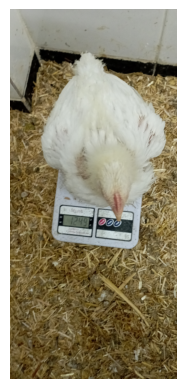

In [7]:
sample = dataset["train"][42]

print("Weight:", sample["weight"])

plt.imshow(sample["image"])
plt.axis("off")

## 2. Data Preparation for Training (PyTorch)

We now convert our dataset into a PyTorch-compatible format.

This includes:
- applying image transformations
- creating a custom Dataset
- preparing a DataLoader for batching

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

### Image Transformations

We resize images and convert them to tensors so they can be used by a neural network.

In [9]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

### Custom PyTorch Dataset

We wrap our dataset into a Pytorch Dataset to:

- apply transformations
- return [image, weight] pairs

In [10]:
class PoultryWeightDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        image = sample["image"]
        weight = sample["weight"]

        if weight is None:
            raise ValueError(f"Missing weight at index {idx}")

        if self.transform:
            image = self.transform(image)

        weight = torch.tensor(float(weight), dtype=torch.float32)

        return image, weight

In [11]:
train_dataset = PoultryWeightDataset(dataset["train"], transform=transform)

### DataLoader

The DataLoader handles batching, shuffling, and efficient data loading during training.

In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

In [13]:
images, weights = next(iter(train_loader))

print("Images shape:", images.shape)
print("Weights shape:", weights.shape)
print(weights.dtype)

Images shape: torch.Size([32, 3, 224, 224])
Weights shape: torch.Size([32])
torch.float32


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

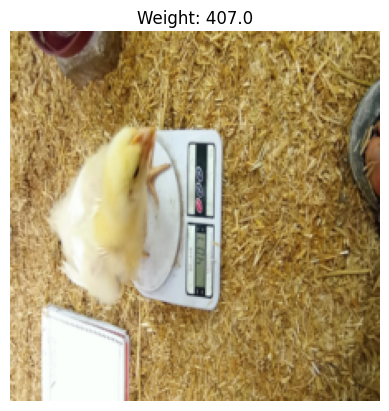

In [14]:
img = images[0].permute(1, 2, 0)

plt.imshow(img)
plt.title(f"Weight: {weights[0].item()}")
plt.axis("off")

### Model and Training Setup

We now define a simple Convolutional Neural Network (CNN) for regression.

In [15]:
import torch.nn as nn
import torch.nn.functional as F

In [16]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # 224 → 112
        x = self.pool(F.relu(self.conv2(x))) # 112 → 56
        x = self.pool(F.relu(self.conv3(x))) # 56 → 28

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x.squeeze(1)

Training Configuration:

In [17]:
device = torch.device("cpu")

model = SimpleCNN().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

### ⚙️ Initial Training Loop

In [18]:
num_epochs = 10

for epoch in range(num_epochs):
    
    model.train()
    running_loss = 0.0

    for images, weights in train_loader:
        images = images.to(device)
        weights = weights.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, weights)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}")

Epoch [1/10] - Loss: 172493.2353
Epoch [2/10] - Loss: 154024.2034
Epoch [3/10] - Loss: 148656.7756
Epoch [4/10] - Loss: 139340.2150
Epoch [5/10] - Loss: 129643.6504
Epoch [6/10] - Loss: 115982.0640
Epoch [7/10] - Loss: 104133.9064
Epoch [8/10] - Loss: 100191.2624
Epoch [9/10] - Loss: 91292.7486
Epoch [10/10] - Loss: 87764.3226


The baseline model shows a consistent decrease in training loss across epochs, indicating that it is successfully learning patterns from the data. However, since no validation split has been used yet, these results only reflect performance on the training set and do not provide insight into the model’s generalization ability. The next steps will focus on introducing a train/validation split, evaluating performance on unseen data, and incorporating more informative metrics and improvements to the training process.

## 3. Train / Validation Split

To properly evaluate our model, we split the dataset into training and validation sets.

This allows us to:
- train the model on one subset
- evaluate its performance on unseen data

This is essential to detect overfitting and assess generalization.

In [19]:
from torch.utils.data import random_split

full_dataset = dataset["train"]

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

print(f"Train size: {len(train_subset)}")
print(f"Validation size: {len(val_subset)}")

Train size: 3808
Validation size: 953


### PyTorch Datasets (Train and Validation)

We wrap both subsets into our custom PyTorch Dataset.

This ensures:
- transformations are applied
- data is returned as (image, weight)

In [20]:
train_dataset = PoultryWeightDataset(train_subset, transform=transform)
val_dataset = PoultryWeightDataset(val_subset, transform=transform)

### DataLoaders

We create separate DataLoaders:

- Training loader → shuffled
- Validation loader → not shuffled

In [21]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

### ⚙️ Training with Validation

We now train the model again, but this time we also compute validation loss. This helps us understand if the model generalizes well.

In [22]:
num_epochs = 10

for epoch in range(num_epochs):
    
    # TRAIN
    model.train()
    train_loss = 0.0

    for images, weights in train_loader:
        images = images.to(device)
        weights = weights.to(device)

        optimizer.zero_grad()

        outputs = model(images).squeeze()
        loss = criterion(outputs, weights)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, weights in val_loader:
            images = images.to(device)
            weights = weights.to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, weights)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

Epoch [1/10] - Train Loss: 78231.7095 - Val Loss: 92136.2918
Epoch [2/10] - Train Loss: 73214.3137 - Val Loss: 105334.1375
Epoch [3/10] - Train Loss: 70282.0510 - Val Loss: 86327.7874
Epoch [4/10] - Train Loss: 64656.0345 - Val Loss: 82825.9844
Epoch [5/10] - Train Loss: 62810.1537 - Val Loss: 80174.4454
Epoch [6/10] - Train Loss: 58440.5035 - Val Loss: 77847.2902
Epoch [7/10] - Train Loss: 54095.9266 - Val Loss: 80506.4038
Epoch [8/10] - Train Loss: 49798.6325 - Val Loss: 70853.2544
Epoch [9/10] - Train Loss: 50549.9839 - Val Loss: 71180.4410
Epoch [10/10] - Train Loss: 43743.3338 - Val Loss: 77573.5062


The model shows consistent learning, with both training and validation loss decreasing over epochs. However, the relatively high loss values and the gap between training and validation performance suggest that the model still struggles to generalize properly. Further improvements are needed, such as target normalization and architectural refinements.

## 4. Target Normalization

The target variable (weight in grams) has large values, which can make training unstable.

We normalize the weights to improve:
- numerical stability
- convergence speed

After training, we convert predictions back to grams for interpretation.

In [23]:
import numpy as np

all_weights = [dataset["train"][i]["weight"] for i in range(len(dataset["train"]))]

mean_weight = np.mean(all_weights)
std_weight = np.std(all_weights)

print(f"Mean weight: {mean_weight:.2f}")
print(f"Std weight: {std_weight:.2f}")

Mean weight: 471.24
Std weight: 392.39


### Custom Dataset with Normalized Targets

We modify our dataset to return normalized weights:

*normalized_weight = (weight - mean) / std*

In [24]:
class PoultryWeightDatasetNormalized(Dataset):
    def __init__(self, hf_dataset, transform=None, mean=0.0, std=1.0):
        self.dataset = hf_dataset
        self.transform = transform
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        image = sample["image"]
        weight = sample["weight"]

        if self.transform:
            image = self.transform(image)

        weight = (weight - self.mean) / self.std
        weight = torch.tensor(weight, dtype=torch.float32)

        return image, weight

### Rebuild Train / Validation Datasets

We now recreate datasets using normalized targets.

In [25]:
train_dataset_norm = PoultryWeightDatasetNormalized(train_subset, transform=transform, mean=mean_weight, std=std_weight)

val_dataset_norm = PoultryWeightDatasetNormalized(val_subset, transform=transform, mean=mean_weight, std=std_weight)

train_loader_norm = DataLoader(train_dataset_norm, batch_size=32, shuffle=True, num_workers=2)
val_loader_norm = DataLoader(val_dataset_norm, batch_size=32, shuffle=False, num_workers=2)

### ⚙️ Training with Normalized Targets

We train the same model again, but using normalized weights.

In [26]:
num_epochs = 10

for epoch in range(num_epochs):

    # TRAIN
    model.train()
    train_loss = 0.0

    for images, weights in train_loader_norm:
        images = images.to(device)
        weights = weights.to(device)

        optimizer.zero_grad()

        outputs = model(images).squeeze()
        loss = criterion(outputs, weights)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader_norm)

    # VALIDATION
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, weights in val_loader_norm:
            images = images.to(device)
            weights = weights.to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, weights)

            val_loss += loss.item()

    val_loss /= len(val_loader_norm)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

Epoch [1/10] - Train Loss: 5833.2914 - Val Loss: 3.3292
Epoch [2/10] - Train Loss: 1.4346 - Val Loss: 1.6890
Epoch [3/10] - Train Loss: 1.0237 - Val Loss: 1.4831
Epoch [4/10] - Train Loss: 0.9976 - Val Loss: 1.4690
Epoch [5/10] - Train Loss: 0.9977 - Val Loss: 1.4705
Epoch [6/10] - Train Loss: 0.9975 - Val Loss: 1.4704
Epoch [7/10] - Train Loss: 0.9972 - Val Loss: 1.4709
Epoch [8/10] - Train Loss: 0.9971 - Val Loss: 1.4699
Epoch [9/10] - Train Loss: 0.9971 - Val Loss: 1.4714
Epoch [10/10] - Train Loss: 0.9970 - Val Loss: 1.4706


### Evaluation (MAE in grams)

We compute Mean Absolute Error (MAE) in the original scale (grams). This gives a more interpretable metric.

In [27]:
model.eval()
mae = 0.0

with torch.no_grad():
    for images, weights in val_loader_norm:
        images = images.to(device)
        weights = weights.to(device)

        outputs = model(images).squeeze()

        # Denormalize
        preds = outputs * std_weight + mean_weight
        targets = weights * std_weight + mean_weight

        mae += torch.abs(preds - targets).sum().item()

mae /= len(val_dataset_norm)

print(f"Validation MAE: {mae:.2f} grams")

Validation MAE: 283.55 grams


### Example Prediction

We visualize a prediction and compare it to the real weight.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

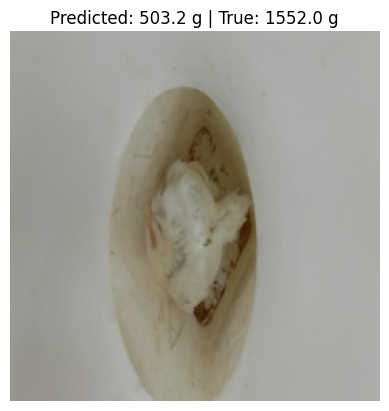

In [28]:
sample = val_dataset_norm[0]

image, weight_norm = sample

model.eval()
with torch.no_grad():
    pred_norm = model(image.unsqueeze(0).to(device)).squeeze()

pred_weight = pred_norm.item() * std_weight + mean_weight
true_weight = weight_norm.item() * std_weight + mean_weight

img = image.permute(1, 2, 0)

plt.imshow(img)
plt.title(f"Predicted: {pred_weight:.1f} g | True: {true_weight:.1f} g")
plt.axis("off")

The model shows improved stability after target normalization, with both training and validation loss converging smoothly. However, the validation MAE (~283 grams) indicates that predictions are still relatively inaccurate. Visual inspection confirms that the model struggles with certain samples, suggesting that further improvements are needed in both model capacity and data processing.